In [122]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [123]:
df=pd.read_csv(r"C:\Users\ASUS\Desktop\Projects\YouTube-Video-Popularity-Prediction\data\processed\youtube_data_cleaned.csv")

In [124]:
df.isnull().sum() # No Null Value.

video_id                0
title                   0
published_at            0
category_id             0
duration                0
view_count              0
like_count              0
comment_count           0
channel_subscribers     0
channel_total_views     0
channel_total_videos    0
dtype: int64

In [125]:
df["duration"]  # PT M S TEMİZLENECEK

0      PT11M39S
1       PT8M14S
2      PT13M13S
3      PT17M18S
4      PT38M38S
         ...   
979       PT36S
980     PT4M30S
981       PT38S
982     PT4M30S
983     PT9M32S
Name: duration, Length: 984, dtype: str

In [126]:
import re

def parse_duration(d):
    match = re.match(r'PT(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?', str(d))
    h = int(match.group(1) or 0)
    m = int(match.group(2) or 0)
    s = int(match.group(3) or 0)
    return h*3600 + m*60 + s

df['duration_seconds'] = df['duration'].apply(parse_duration)

In [127]:
df['duration_seconds']

0       699
1       494
2       793
3      1038
4      2318
       ... 
979      36
980     270
981      38
982     270
983     572
Name: duration_seconds, Length: 984, dtype: int64

In [128]:
df.dtypes

video_id                  str
title                     str
published_at              str
category_id             int64
duration                  str
view_count              int64
like_count              int64
comment_count           int64
channel_subscribers     int64
channel_total_views     int64
channel_total_videos    int64
duration_seconds        int64
dtype: object

In [129]:
df['published_at'] = pd.to_datetime(df['published_at'], utc=True)

In [130]:
df['published_at'].iloc[0]
df['published_at'] = df['published_at'].dt.floor('min')
df['published_at']


0     2025-12-22 12:01:00+00:00
1     2026-01-08 14:03:00+00:00
2     2026-01-06 13:00:00+00:00
3     2026-05-02 10:54:00+00:00
4     2026-01-02 11:00:00+00:00
                 ...           
979   2025-02-14 13:40:00+00:00
980   2026-03-26 06:45:00+00:00
981   2025-04-28 16:09:00+00:00
982   2026-01-25 11:09:00+00:00
983   2025-10-26 17:30:00+00:00
Name: published_at, Length: 984, dtype: datetime64[us, UTC]

In [131]:
from datetime import datetime, timezone

now = datetime.now(timezone.utc)
df['days_since_published'] = (now - df['published_at']).dt.days
df['days_since_published'] = df['days_since_published'].replace(0, 1)  

df['daily_avg_views'] = df['view_count'] / df['days_since_published']

In [132]:
df['daily_avg_views']

0      2888.343284
1        38.222222
2      3349.991597
3         0.000000
4       204.390244
          ...     
979     461.930337
980       1.500000
981    2995.051075
982       5.950000
983      66.356021
Name: daily_avg_views, Length: 984, dtype: float64

In [133]:
threshold = df['daily_avg_views'].median()
threshold 

np.float64(297.506044413801)

In [134]:
df.head()

,video_id,title,published_at,category_id,duration,view_count,like_count,comment_count,channel_subscribers,channel_total_views,channel_total_videos,duration_seconds,days_since_published,daily_avg_views
0,zt0JA5rxdfM,"AI Trends 2026: Quantum, Agentic AI & Smarter ...",2025-12-22 12:01:00+00:00,27,PT11M39S,387038,9420,1085,1670000,116404163,1630,699,134,2888.343284
1,QkRHuoHygiE,Generative AI Trends in 2026 | Top 10 Generati...,2026-01-08 14:03:00+00:00,27,PT8M14S,4472,132,4,4440000,465475950,11848,494,117,38.222222
2,B23W1gRT9eY,Top 6 AI Trends That Will Define 2026 (backed ...,2026-01-06 13:00:00+00:00,27,PT13M13S,398649,8651,830,1710000,95539701,304,793,119,3349.991597
3,VunjURBzNow,"Top 20 AI & ML Trends in 2026 | Agents, Genera...",2026-05-02 10:54:00+00:00,24,PT17M18S,0,0,0,318,78,16,1038,3,0.000000
4,ARXS-uk19h8,AI year in review: Trends shaping 2026,2026-01-02 11:00:00+00:00,27,PT38M38S,25140,441,43,1670000,116404163,1630,2318,123,204.390244


In [135]:
df['is_popular'] = (df['daily_avg_views'] >= threshold).astype(int)
df['is_popular']


0      1
1      0
2      1
3      0
4      0
      ..
979    1
980    0
981    1
982    0
983    0
Name: is_popular, Length: 984, dtype: int64

In [136]:
df['publish_hour'] = df['published_at'].dt.hour
df['publish_dayofweek'] = df['published_at'].dt.dayofweek
df['is_weekend'] = df['publish_dayofweek'].isin([5, 6]).astype(int)
df['is_prime_time'] = df['publish_hour'].between(17, 22).astype(int) # Select those hours as prime time .

In [137]:
df['title_word_count'] = df['title'].str.split().str.len()
df['title_char_count'] = df['title'].str.len()
df['title_upper_ratio'] = df['title'].apply(lambda x: sum(1 for c in str(x) if c.isupper()) / max(len(str(x)), 1))
df['title_has_question'] = df['title'].str.contains(r'\?', na=False).astype(int)
df['title_has_exclamation'] = df['title'].str.contains(r'!', na=False).astype(int)

In [138]:
# Log1p transform skewed numeric features (safe for zeros)
log_base_cols = [
    "view_count",
    "like_count",
    "comment_count",
    "channel_subscribers",
    "duration_seconds",
]
log_cols = [col for col in log_base_cols if col in df.columns]
for col in log_cols:
    df[f"{col}_log1p"] = np.log1p(df[col])

# One-hot encode category_id
category_cols = []
if "category_id" in df.columns:
    category_dummies = pd.get_dummies(
        df["category_id"].astype("category"),
        prefix="category",
        drop_first=False,
    )
    df = pd.concat([df, category_dummies], axis=1)
    category_cols = list(category_dummies.columns)

In [139]:
# Additional feature engineering
if "daily_avg_views" in df.columns:
    df["daily_avg_views_log1p"] = np.log1p(df["daily_avg_views"])
if "view_count" in df.columns and "channel_subscribers" in df.columns:
    df["views_per_subscriber"] = df["view_count"] / (df["channel_subscribers"] + 1)
if "daily_avg_views" in df.columns and "channel_subscribers" in df.columns:
    df["daily_views_per_subscriber"] = df["daily_avg_views"] / (df["channel_subscribers"] + 1)
if "channel_total_views" in df.columns and "channel_total_videos" in df.columns:
    df["channel_efficiency"] = df["channel_total_views"] / (df["channel_total_videos"] + 1)
if "days_since_published" in df.columns:
    df["recency_score"] = 1 / (df["days_since_published"] + 1)
if "publish_hour" in df.columns:
    df["prime_time_distance"] = (df["publish_hour"] - 19).abs()
if "daily_avg_views" in df.columns and "category_id" in df.columns:
    category_mean = df.groupby("category_id")["daily_avg_views"].transform("mean")
    df["daily_views_vs_category"] = df["daily_avg_views"] / (category_mean + 1e-9)

if "title" in df.columns:
    title_lower = df["title"].astype(str).str.lower()
    trend_keywords = ["ai", "trend", "trends", "2026", "2025", "new", "update", "viral", "shorts"]
    hype_keywords = ["super", "shock", "amazing", "insane", "best", "worst", "wow", "exclusive"]
    keyword_pattern = "|".join(trend_keywords + hype_keywords)
    df["title_trend_kw"] = title_lower.str.contains("|".join(trend_keywords), regex=True).astype(int)
    df["title_hype_kw"] = title_lower.str.contains("|".join(hype_keywords), regex=True).astype(int)
    df["title_kw_count"] = title_lower.str.count(keyword_pattern)

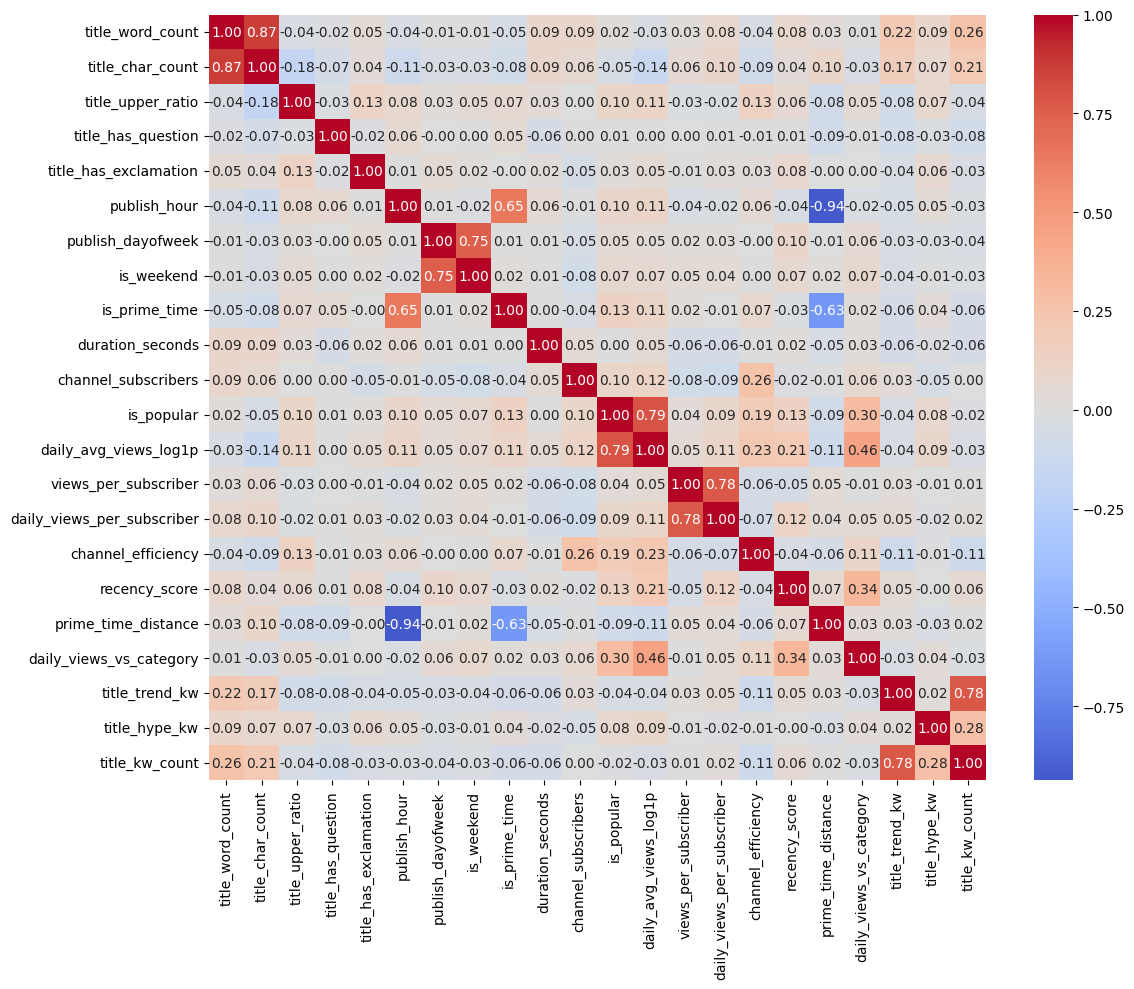

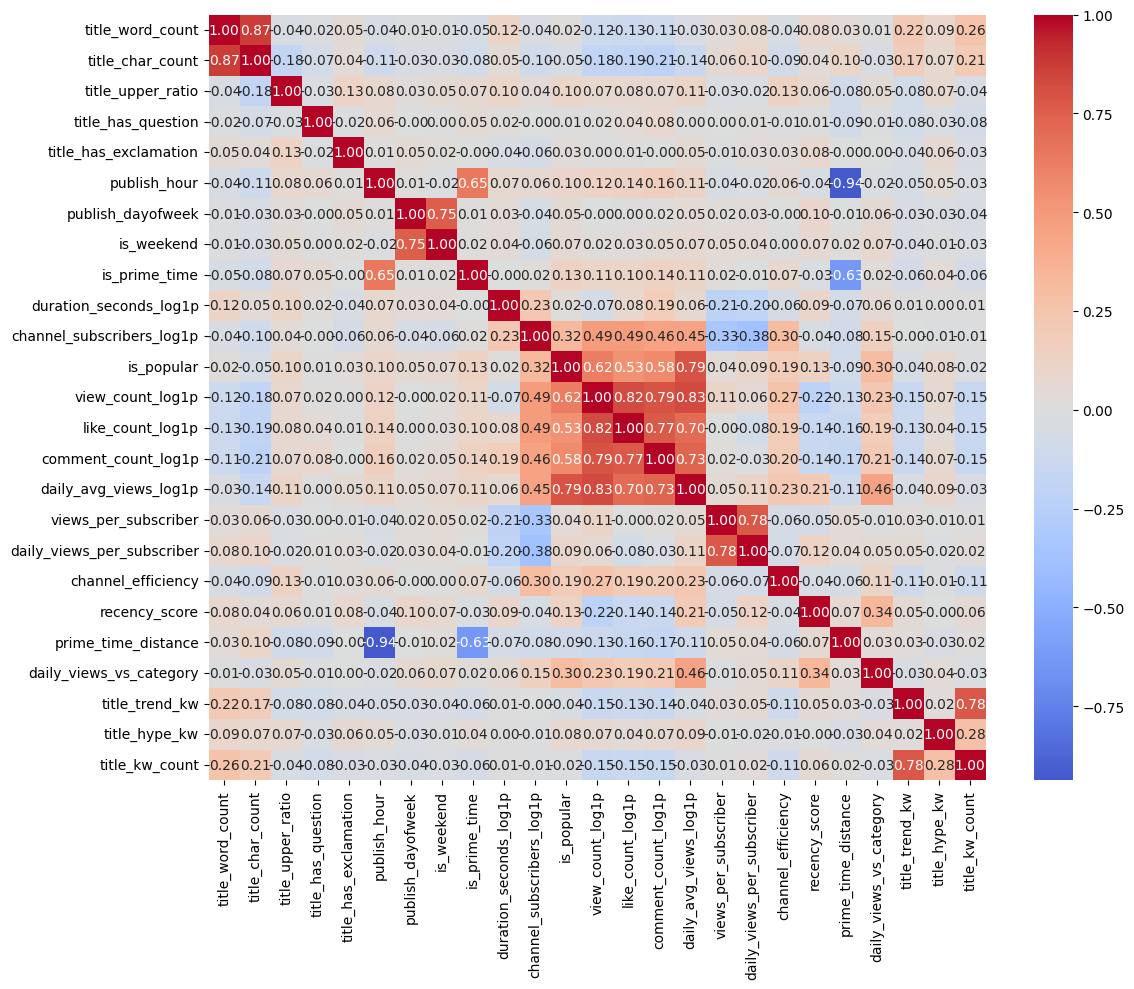

In [140]:
base_cols = [
    "title_word_count", "title_char_count", "title_upper_ratio",
    "title_has_question", "title_has_exclamation",
    "publish_hour", "publish_dayofweek", "is_weekend", "is_prime_time",
    "duration_seconds", "channel_subscribers", "is_popular",
]

engineered_cols = [
    "daily_avg_views_log1p",
    "views_per_subscriber",
    "daily_views_per_subscriber",
    "channel_efficiency",
    "recency_score",
    "prime_time_distance",
    "daily_views_vs_category",
    "title_trend_kw",
    "title_hype_kw",
    "title_kw_count",
]
engineered_cols = [col for col in engineered_cols if col in df.columns]

feature_cols_raw = base_cols + engineered_cols
feature_cols_log = [
    "title_word_count", "title_char_count", "title_upper_ratio",
    "title_has_question", "title_has_exclamation",
    "publish_hour", "publish_dayofweek", "is_weekend", "is_prime_time",
    "duration_seconds_log1p", "channel_subscribers_log1p", "is_popular",
]
feature_cols_log += [f"{col}_log1p" for col in log_cols if f"{col}_log1p" not in feature_cols_log]
feature_cols_log += [col for col in engineered_cols if col not in feature_cols_log]

import os
output_dir = r"C:\Users\ASUS\Desktop\Projects\YouTube-Video-Popularity-Prediction\results\plots"
os.makedirs(output_dir, exist_ok=True)

# Raw features heatmap
corr_raw = df[feature_cols_raw].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_raw, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "feature_correlation_raw_heatmap.png"), dpi=300, bbox_inches="tight")
plt.show()

# Log-transformed features heatmap
corr_log = df[feature_cols_log].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_log, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "feature_correlation_log_heatmap.png"), dpi=300, bbox_inches="tight")
plt.show()

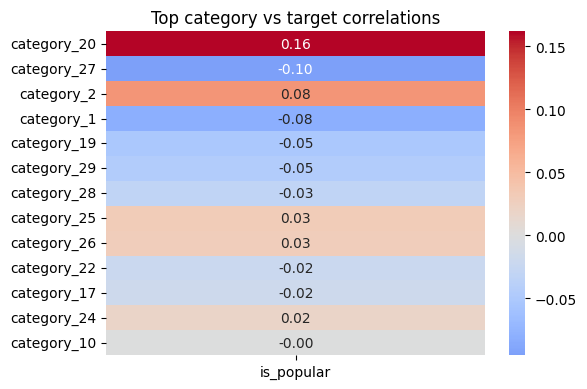

In [141]:
if category_cols and "is_popular" in df.columns:
    cat_target_corr = (
        df[category_cols + ["is_popular"]]
        .corr()["is_popular"]
        .drop("is_popular")
        .sort_values(key=lambda s: s.abs(), ascending=False)
    )
    top_n = 20
    cat_target_corr = cat_target_corr.head(top_n)
    plt.figure(figsize=(6, max(4, 0.3 * len(cat_target_corr))))
    sns.heatmap(cat_target_corr.to_frame("is_popular"), annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title("Top category vs target correlations")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "category_target_correlation_heatmap.png"), dpi=300, bbox_inches="tight")
    plt.show()

In [142]:
df

,video_id,title,published_at,category_id,duration,view_count,like_count,comment_count,channel_subscribers,channel_total_views,...,daily_avg_views_log1p,views_per_subscriber,daily_views_per_subscriber,channel_efficiency,recency_score,prime_time_distance,daily_views_vs_category,title_trend_kw,title_hype_kw,title_kw_count
0,zt0JA5rxdfM,"AI Trends 2026: Quantum, Agentic AI & Smarter ...",2025-12-22 12:01:00+00:00,27,PT11M39S,387038,9420,1085,1670000,116404163,...,7.968785,0.231759,0.001730,71369.811772,0.007407,7,3.344615,1,0,4
1,QkRHuoHygiE,Generative AI Trends in 2026 | Top 10 Generati...,2026-01-08 14:03:00+00:00,27,PT8M14S,4472,132,4,4440000,465475950,...,3.669243,0.001007,0.000009,39283.985990,0.008475,5,0.044260,1,0,6
2,B23W1gRT9eY,Top 6 AI Trends That Will Define 2026 (backed ...,2026-01-06 13:00:00+00:00,27,PT13M13S,398649,8651,830,1710000,95539701,...,8.117012,0.233128,0.001959,313244.921311,0.008333,6,3.879190,1,0,3
3,VunjURBzNow,"Top 20 AI & ML Trends in 2026 | Agents, Genera...",2026-05-02 10:54:00+00:00,24,PT17M18S,0,0,0,318,78,...,0.000000,0.000000,0.000000,4.588235,0.250000,9,0.000000,1,0,4
4,ARXS-uk19h8,AI year in review: Trends shaping 2026,2026-01-02 11:00:00+00:00,27,PT38M38S,25140,441,43,1670000,116404163,...,5.324912,0.015054,0.000122,71369.811772,0.008065,8,0.236678,1,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
979,GlgTI_Gd9_g,MAHARASHTRA to Get INNOVATION City like GIFT c...,2025-02-14 13:40:00+00:00,27,PT36S,205559,8283,239,66000,53214805,...,6.137577,3.114483,0.006999,202337.661597,0.002242,6,0.534902,1,0,1
980,u25zjz6x1ow,HydroStride X 💧⚡ | Smart Eco Public Infrastruc...,2026-03-26 06:45:00+00:00,27,PT4M30S,60,13,0,2550,169550,...,0.916291,0.023520,0.000588,662.304688,0.024390,13,0.001737,1,0,1
981,WoH2BEKb4Wo,Top 10 most planned cities in India #top10 #pl...,2025-04-28 16:09:00+00:00,27,PT38S,1114159,20962,642,89900,77534922,...,8.005050,12.393177,0.033315,228043.888235,0.002681,3,3.468180,1,1,2
982,bKfetn_IP0Y,Smart Cities Week 1 | NPTEL ANSWERS 2026 #npte...,2026-01-25 11:09:00+00:00,27,PT4M30S,595,8,0,33500,5854741,...,1.938742,0.017761,0.000178,982.503944,0.009901,8,0.006890,1,0,2


In [143]:
output_path = r"C:\Users\ASUS\Desktop\Projects\YouTube-Video-Popularity-Prediction\data\processed\features_data.csv"
cols = [col for col in df.columns if col != "is_popular"]
cols += ["is_popular"]
df[cols].to_csv(output_path, index=False)
output_path

'C:\\Users\\ASUS\\Desktop\\Projects\\YouTube-Video-Popularity-Prediction\\data\\processed\\features_data.csv'

In [144]:
filtered_cols = [
    "channel_subscribers",
    "title_word_count",
    "title_char_count",
    "title_upper_ratio",
    "title_has_question",
    "title_has_exclamation",
    "publish_dayofweek",
    "publish_hour",
    "is_weekend",
    "is_prime_time",
]
filtered_cols += [f"{col}_log1p" for col in log_cols]
filtered_cols += [col for col in engineered_cols if col not in filtered_cols]
filtered_cols += category_cols
filtered_cols += ["is_popular"]

filtered_output_path = r"C:\Users\ASUS\Desktop\Projects\YouTube-Video-Popularity-Prediction\data\processed\filtered_feature_data.csv"
df[filtered_cols].to_csv(filtered_output_path, index=False)
filtered_output_path

'C:\\Users\\ASUS\\Desktop\\Projects\\YouTube-Video-Popularity-Prediction\\data\\processed\\filtered_feature_data.csv'

In [145]:
new_data=pd.read_csv(r"C:\Users\ASUS\Desktop\Projects\YouTube-Video-Popularity-Prediction\data\processed\filtered_feature_data.csv")

In [146]:
new_data.columns

Index(['channel_subscribers', 'title_word_count', 'title_char_count',
       'title_upper_ratio', 'title_has_question', 'title_has_exclamation',
       'publish_dayofweek', 'publish_hour', 'is_weekend', 'is_prime_time',
       'view_count_log1p', 'like_count_log1p', 'comment_count_log1p',
       'channel_subscribers_log1p', 'duration_seconds_log1p',
       'daily_avg_views_log1p', 'views_per_subscriber',
       'daily_views_per_subscriber', 'channel_efficiency', 'recency_score',
       'prime_time_distance', 'daily_views_vs_category', 'title_trend_kw',
       'title_hype_kw', 'title_kw_count', 'category_1', 'category_2',
       'category_10', 'category_17', 'category_19', 'category_20',
       'category_22', 'category_24', 'category_25', 'category_26',
       'category_27', 'category_28', 'category_29', 'is_popular'],
      dtype='str')

In [147]:
new_data.size

38376

In [148]:
new_data.shape

(984, 39)